# Multi-Resolution Comparison: Learned Activations vs SatCLIP

**Goal**: Test learned activations at different resolutions and compare to SatCLIP baselines

## Setup
- **Resolutions**: 15-min (~28km), 30-min (~56km), 1-degree (~111km)
- **Models**: RFF, Spline, ReLU, SatCLIP L=10, SatCLIP L=40
- **Task**: Population density regression

## Key Insights from Notebook 14
At 15-min resolution:
- **RFF (n=25)**: R² = 0.743 (winner, +1.3% over ReLU)
- **Spline (k=10)**: R² = 0.735 (+0.6% over ReLU)
- **ReLU**: R² = 0.729 (baseline)

Both learned activations beat ReLU! Now let's see how they perform at different resolutions.

In [3]:
# Setup
import os
import sys

if 'COLAB_GPU' in os.environ:
    !rm -rf sample_data .config satclip gpw_data 2>/dev/null
    !git clone https://github.com/1hamzaiqbal/satclip.git
    !pip install lightning torchgeo huggingface_hub rasterio --quiet
    sys.path.append('./satclip/satclip')
else:
    sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'satclip'))

Cloning into 'satclip'...
remote: Enumerating objects: 503, done.
remote: Counting objects: 100% (182/182), done.
remote: Compressing objects: 100% (45/45), done.
remote: Total 503 (delta 155), reused 142 (delta 137), pack-reused 321 (from 2)
Receiving objects: 100% (503/503), 82.01 MiB | 14.60 MiB/s, done.
Resolving deltas: 100% (258/258), done.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
GPW_DIR = './gpw_data'
os.makedirs(GPW_DIR, exist_ok=True)

print("Extracting GPW data...")
with zipfile.ZipFile('/content/drive/MyDrive/grad/learned_activations/dataverse_files.zip', 'r') as z:
    z.extractall(GPW_DIR)

with zipfile.ZipFile(f'{GPW_DIR}/gpw-v4-population-density-rev11_2020_15_min_tif.zip', 'r') as z:
    z.extractall(GPW_DIR)
print("Done!")

Mounted at /content/drive
Extracting GPW data...
Done!


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import time
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge
from huggingface_hub import hf_hub_download
from load import get_satclip

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


---
## Activation Classes (from Notebook 14)

In [6]:
# =============================================================================
# RFF ACTIVATION (Random Fourier Features)
# =============================================================================

class RFFActivation(nn.Module):
    """Random Fourier Features activation."""
    def __init__(self, n_features=25, max_freq=10.0, learnable_freq=False):
        super().__init__()
        self.n_features = n_features

        freqs = torch.linspace(0.1, max_freq, n_features)
        if learnable_freq:
            self.freqs = nn.Parameter(freqs)
        else:
            self.register_buffer('freqs', freqs)

        self.sin_coeff = nn.Parameter(torch.randn(n_features) * 0.1)
        self.cos_coeff = nn.Parameter(torch.randn(n_features) * 0.1)
        self.scale = nn.Parameter(torch.ones(1))
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        wx = x.unsqueeze(-1) * self.freqs
        sin_part = (torch.sin(wx) * self.sin_coeff).sum(-1)
        cos_part = (torch.cos(wx) * self.cos_coeff).sum(-1)
        return self.scale * (sin_part + cos_part) + self.bias

    def num_params(self):
        return sum(p.numel() for p in self.parameters())


# =============================================================================
# SPLINE ACTIVATION
# =============================================================================

class SplineActivation(nn.Module):
    """Cubic B-spline activation with learnable control points."""
    def __init__(self, n_knots=10, input_range=(-3.0, 3.0), init='relu'):
        super().__init__()
        self.n_knots = n_knots
        self.input_range = input_range

        knot_x = torch.linspace(input_range[0], input_range[1], n_knots)
        self.register_buffer('knot_x', knot_x)

        if init == 'relu':
            knot_y = torch.relu(knot_x)
        elif init == 'linear':
            knot_y = knot_x.clone()
        else:
            knot_y = torch.randn(n_knots) * 0.1

        self.knot_y = nn.Parameter(knot_y)

    def forward(self, x):
        x_clamped = torch.clamp(x, self.input_range[0], self.input_range[1])
        x_norm = (x_clamped - self.input_range[0]) / (self.input_range[1] - self.input_range[0])
        x_idx = x_norm * (self.n_knots - 1)

        idx_low = torch.floor(x_idx).long()
        idx_high = torch.clamp(idx_low + 1, max=self.n_knots - 1)
        idx_low = torch.clamp(idx_low, max=self.n_knots - 1)

        weight = x_idx - idx_low.float()
        y_low = self.knot_y[idx_low]
        y_high = self.knot_y[idx_high]

        return y_low + weight * (y_high - y_low)

    def num_params(self):
        return self.knot_y.numel()


# =============================================================================
# LOCATION ENCODER (Modular)
# =============================================================================

class LocationEncoder(nn.Module):
    """Modular location encoder that can use any activation."""
    def __init__(self, activation_class, activation_kwargs=None,
                 n_layers=3, hidden_dim=256, output_dim=256):
        super().__init__()

        if activation_kwargs is None:
            activation_kwargs = {}

        dims = [2] + [hidden_dim] * n_layers + [output_dim]
        self.linears = nn.ModuleList([
            nn.Linear(dims[i], dims[i+1])
            for i in range(len(dims) - 1)
        ])

        self.activations = nn.ModuleList([
            activation_class(**activation_kwargs)
            for _ in range(n_layers)
        ])

        for linear in self.linears:
            nn.init.kaiming_normal_(linear.weight)
            nn.init.zeros_(linear.bias)

    def forward(self, coords):
        x = coords / torch.tensor([180., 90.], device=coords.device)

        for i, (linear, act) in enumerate(zip(self.linears[:-1], self.activations)):
            x = act(linear(x))

        x = self.linears[-1](x)
        return x

    def num_params(self):
        return sum(p.numel() for p in self.parameters())


# =============================================================================
# RELU ENCODER (Baseline)
# =============================================================================

class ReLUEncoder(nn.Module):
    def __init__(self, n_layers=3, hidden_dim=256, output_dim=256):
        super().__init__()
        dims = [2] + [hidden_dim] * n_layers + [output_dim]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims) - 2:
                layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, coords):
        x = coords / torch.tensor([180., 90.], device=coords.device)
        return self.net(x)

    def num_params(self):
        return sum(p.numel() for p in self.parameters())

print("Activation classes loaded!")

Activation classes loaded!


---
## Multi-Resolution Data Loading

In [7]:
# Load full resolution data (15-min)
Image.MAX_IMAGE_PIXELS = None

print("Loading population data...")
img = Image.open(f'{GPW_DIR}/gpw_v4_population_density_rev11_2020_15_min.tif')
pop_data_full = np.array(img)
h, w = pop_data_full.shape
lons_full = np.linspace(-180 + 180/w, 180 - 180/w, w)
lats_full = np.linspace(90 - 90/h, -90 + 90/h, h)
print(f"Full resolution: {pop_data_full.shape}")


def downsample_data(data, lons, lats, factor):
    """Downsample by averaging factor x factor blocks."""
    if factor == 1:
        return data, lons, lats

    h, w = data.shape
    new_h, new_w = h // factor, w // factor

    # Average blocks
    data_reshaped = data[:new_h*factor, :new_w*factor].reshape(new_h, factor, new_w, factor)
    data_down = np.nanmean(data_reshaped, axis=(1, 3))

    # Downsample coordinates (take center of each block)
    lons_down = lons[::factor][:new_w]
    lats_down = lats[::factor][:new_h]

    return data_down, lons_down, lats_down


# Create multi-resolution datasets
RESOLUTIONS = {
    '15-min': {'factor': 1, 'desc': '~28km'},
    '30-min': {'factor': 2, 'desc': '~56km'},
    '1-degree': {'factor': 4, 'desc': '~111km'},
}

datasets = {}
for name, cfg in RESOLUTIONS.items():
    data, lons, lats = downsample_data(pop_data_full, lons_full, lats_full, cfg['factor'])
    datasets[name] = {'data': data, 'lons': lons, 'lats': lats}
    print(f"  {name:10s} {cfg['desc']:8s}: {data.shape}")

print("\nAll resolutions loaded!")

Loading population data...
Full resolution: (720, 1440)
  15-min     ~28km   : (720, 1440)
  30-min     ~56km   : (360, 720)
  1-degree   ~111km  : (180, 360)

All resolutions loaded!


In [8]:
# Spatial blocking sampling (same as notebook 14)
def sample_blocked(data, lons, lats, n_samples=15000, grid_size=5.0, test_ratio=0.3, seed=42):
    np.random.seed(seed)
    valid = data > -1e30

    # Grid
    n_lon = int(360 / grid_size)
    n_lat = int(180 / grid_size)
    n_cells = n_lon * n_lat

    test_cells = set(np.random.choice(n_cells, int(n_cells * test_ratio), replace=False))

    # Sample points
    valid_idx = np.where(valid)
    n_valid = len(valid_idx[0])
    sample_idx = np.random.choice(n_valid, min(n_samples, n_valid), replace=False)

    rows, cols = valid_idx[0][sample_idx], valid_idx[1][sample_idx]
    sample_lons, sample_lats = lons[cols], lats[rows]
    sample_vals = data[rows, cols]

    # Assign to train/test
    train_mask = []
    for lon, lat in zip(sample_lons, sample_lats):
        cell = int((lat + 90) / grid_size) * n_lon + int((lon + 180) / grid_size)
        cell = min(cell, n_cells - 1)
        train_mask.append(cell not in test_cells)
    train_mask = np.array(train_mask)

    coords = np.stack([sample_lons, sample_lats], axis=1)
    return coords[train_mask], sample_vals[train_mask], coords[~train_mask], sample_vals[~train_mask]


# Sample all resolutions
print("Sampling with spatial blocking...")
for name in RESOLUTIONS:
    ds = datasets[name]
    coords_train, vals_train, coords_test, vals_test = sample_blocked(
        ds['data'], ds['lons'], ds['lats'], n_samples=15000
    )
    ds['coords_train'] = coords_train
    ds['vals_train'] = vals_train
    ds['coords_test'] = coords_test
    ds['vals_test'] = vals_test
    print(f"  {name:10s}: train={len(coords_train):5d}, test={len(coords_test):4d}")

print("Done!")

Sampling with spatial blocking...
  15-min    : train=10532, test=4468
  30-min    : train=10456, test=4544
  1-degree  : train=10165, test=4402
Done!


---
## Training & Evaluation Functions

In [9]:
class PopulationPredictor(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder
        self.head = nn.Sequential(
            nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 1)
        )

    def forward(self, coords):
        return self.head(self.encoder(coords)).squeeze(-1)


def train_and_evaluate(encoder_name, encoder, coords_train, vals_train,
                       coords_test, vals_test, epochs=100, batch_size=256, lr=1e-3, verbose=False):
    """Train encoder and return results."""
    model = PopulationPredictor(encoder).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    train_X = torch.tensor(coords_train, dtype=torch.float32)
    train_y = torch.tensor(np.log1p(vals_train), dtype=torch.float32)
    test_X = torch.tensor(coords_test, dtype=torch.float32).to(device)
    test_y = torch.tensor(np.log1p(vals_test), dtype=torch.float32)

    loader = DataLoader(TensorDataset(train_X, train_y),
                       batch_size=batch_size, shuffle=True)

    start = time.time()
    best_r2 = -float('inf')

    for epoch in range(epochs):
        model.train()
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            loss = loss_fn(model(X), y)
            loss.backward()
            opt.step()

        model.eval()
        with torch.no_grad():
            pred = model(test_X).cpu().numpy()
        r2 = r2_score(test_y.numpy(), pred)
        best_r2 = max(best_r2, r2)

        if verbose and (epoch + 1) % 20 == 0:
            print(f"    Epoch {epoch+1:3d}: R²={r2:.4f}")

    train_time = time.time() - start
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    return {
        'model': encoder_name,
        'r2': best_r2,
        'params': n_params,
        'efficiency': best_r2 / (n_params / 10000),
        'time': train_time,
    }


def evaluate_satclip(model_name, satclip_model, coords_train, vals_train, coords_test, vals_test):
    """Evaluate SatCLIP model with Ridge regression head."""
    start = time.time()

    # Get model dtype (SatCLIP uses float64)
    model_dtype = next(satclip_model.parameters()).dtype

    # Get embeddings - match SatCLIP's dtype
    train_X = torch.tensor(coords_train, dtype=model_dtype).to(device)
    test_X = torch.tensor(coords_test, dtype=model_dtype).to(device)
    train_y = np.log1p(vals_train)
    test_y = np.log1p(vals_test)

    with torch.no_grad():
        train_emb = satclip_model(train_X).cpu().numpy()
        test_emb = satclip_model(test_X).cpu().numpy()

    # Train Ridge regression
    ridge = Ridge(alpha=1.0)
    ridge.fit(train_emb, train_y)
    pred = ridge.predict(test_emb)
    r2 = r2_score(test_y, pred)

    train_time = time.time() - start
    n_params = sum(p.numel() for p in satclip_model.parameters())

    return {
        'model': model_name,
        'r2': r2,
        'params': n_params,
        'efficiency': r2 / (n_params / 10000),
        'time': train_time,
    }

print("Functions loaded!")

Functions loaded!


---
## Load SatCLIP Models

In [10]:
print("Loading SatCLIP models...")

print("\n  L=10 (100 features)...")
satclip_l10 = get_satclip(
    hf_hub_download("microsoft/SatCLIP-ViT16-L10", "satclip-vit16-l10.ckpt"),
    device=device,
)
satclip_l10.eval()
print(f"    Params: {sum(p.numel() for p in satclip_l10.parameters()):,}")

print("\n  L=40 (1600 features)...")
satclip_l40 = get_satclip(
    hf_hub_download("microsoft/SatCLIP-ViT16-L40", "satclip-vit16-l40.ckpt"),
    device=device,
)
satclip_l40.eval()
print(f"    Params: {sum(p.numel() for p in satclip_l40.parameters()):,}")

print("\nSatCLIP models loaded!")

Loading SatCLIP models...

  L=10 (100 features)...


satclip-vit16-l10.ckpt:   0%|          | 0.00/103M [00:00<?, ?B/s]

using pretrained moco vit16
Downloading: "https://hf.co/torchgeo/vit_small_patch16_224_sentinel2_all_moco/resolve/1cb683f6c14739634cdfaaceb076529adf898c74/vit_small_patch16_224_sentinel2_all_moco-67c9032d.pth" to /root/.cache/torch/hub/checkpoints/vit_small_patch16_224_sentinel2_all_moco-67c9032d.pth


100%|██████████| 86.5M/86.5M [00:15<00:00, 5.91MB/s]


    Params: 445,696

  L=40 (1600 features)...


satclip-vit16-l40.ckpt:   0%|          | 0.00/121M [00:00<?, ?B/s]

using pretrained moco vit16
    Params: 1,213,696

SatCLIP models loaded!


---
## Run Multi-Resolution Experiments

In [11]:
print("="*80)
print("MULTI-RESOLUTION COMPARISON")
print("="*80)

all_results = []

for res_name in ['15-min', '30-min', '1-degree']:
    print(f"\n{'='*80}")
    print(f"RESOLUTION: {res_name} ({RESOLUTIONS[res_name]['desc']})")
    print(f"{'='*80}")

    ds = datasets[res_name]
    coords_train = ds['coords_train']
    vals_train = ds['vals_train']
    coords_test = ds['coords_test']
    vals_test = ds['vals_test']

    # 1. RFF
    print("\n  [1/5] RFF (n=25)...")
    enc_rff = LocationEncoder(RFFActivation, {'n_features': 25}, n_layers=3)
    res = train_and_evaluate('RFF (n=25)', enc_rff, coords_train, vals_train,
                            coords_test, vals_test, epochs=100)
    res['resolution'] = res_name
    all_results.append(res)
    print(f"    R² = {res['r2']:.4f}, Efficiency = {res['efficiency']:.4f}")

    # 2. Spline
    print("\n  [2/5] Spline (k=10)...")
    enc_spline = LocationEncoder(SplineActivation, {'n_knots': 10, 'init': 'relu'}, n_layers=3)
    res = train_and_evaluate('Spline (k=10)', enc_spline, coords_train, vals_train,
                            coords_test, vals_test, epochs=100)
    res['resolution'] = res_name
    all_results.append(res)
    print(f"    R² = {res['r2']:.4f}, Efficiency = {res['efficiency']:.4f}")

    # 3. ReLU
    print("\n  [3/5] ReLU (baseline)...")
    enc_relu = ReLUEncoder(n_layers=3)
    res = train_and_evaluate('ReLU (baseline)', enc_relu, coords_train, vals_train,
                            coords_test, vals_test, epochs=100)
    res['resolution'] = res_name
    all_results.append(res)
    print(f"    R² = {res['r2']:.4f}, Efficiency = {res['efficiency']:.4f}")

    # 4. SatCLIP L=10
    print("\n  [4/5] SatCLIP L=10...")
    res = evaluate_satclip('SatCLIP L=10', satclip_l10, coords_train, vals_train,
                          coords_test, vals_test)
    res['resolution'] = res_name
    all_results.append(res)
    print(f"    R² = {res['r2']:.4f}, Efficiency = {res['efficiency']:.4f}")

    # 5. SatCLIP L=40
    print("\n  [5/5] SatCLIP L=40...")
    res = evaluate_satclip('SatCLIP L=40', satclip_l40, coords_train, vals_train,
                          coords_test, vals_test)
    res['resolution'] = res_name
    all_results.append(res)
    print(f"    R² = {res['r2']:.4f}, Efficiency = {res['efficiency']:.4f}")

df_all = pd.DataFrame(all_results)
print("\n\nAll experiments complete!")

MULTI-RESOLUTION COMPARISON

RESOLUTION: 15-min (~28km)

  [1/5] RFF (n=25)...
    R² = 0.7329, Efficiency = 0.0317

  [2/5] Spline (k=10)...
    R² = 0.7281, Efficiency = 0.0315

  [3/5] ReLU (baseline)...
    R² = 0.7221, Efficiency = 0.0312

  [4/5] SatCLIP L=10...
    R² = 0.7038, Efficiency = 0.0158

  [5/5] SatCLIP L=40...
    R² = 0.6178, Efficiency = 0.0051

RESOLUTION: 30-min (~56km)

  [1/5] RFF (n=25)...
    R² = 0.7714, Efficiency = 0.0333

  [2/5] Spline (k=10)...
    R² = 0.7771, Efficiency = 0.0336

  [3/5] ReLU (baseline)...
    R² = 0.7614, Efficiency = 0.0329

  [4/5] SatCLIP L=10...
    R² = 0.7445, Efficiency = 0.0167

  [5/5] SatCLIP L=40...
    R² = 0.6557, Efficiency = 0.0054

RESOLUTION: 1-degree (~111km)

  [1/5] RFF (n=25)...
    R² = 0.7942, Efficiency = 0.0343

  [2/5] Spline (k=10)...
    R² = 0.7830, Efficiency = 0.0339

  [3/5] ReLU (baseline)...
    R² = 0.7867, Efficiency = 0.0340

  [4/5] SatCLIP L=10...
    R² = 0.7674, Efficiency = 0.0172

  [5/5] Sa

---
## Results & Analysis

In [12]:
print("="*80)
print("RESULTS BY RESOLUTION")
print("="*80)

for res_name in ['15-min', '30-min', '1-degree']:
    print(f"\n{res_name} ({RESOLUTIONS[res_name]['desc']}):")
    df_res = df_all[df_all['resolution'] == res_name].copy()
    df_res = df_res.sort_values('r2', ascending=False)
    print(df_res[['model', 'r2', 'params', 'efficiency']].round(4).to_string(index=False))

print("\n" + "="*80)
print("SUMMARY")
print("="*80)

# Best model at each resolution
print("\nBest R² at each resolution:")
for res_name in ['15-min', '30-min', '1-degree']:
    df_res = df_all[df_all['resolution'] == res_name]
    best = df_res.loc[df_res['r2'].idxmax()]
    print(f"  {res_name:10s}: {best['model']:20s} (R² = {best['r2']:.4f})")

# Best efficiency at each resolution
print("\nBest efficiency at each resolution:")
for res_name in ['15-min', '30-min', '1-degree']:
    df_res = df_all[df_all['resolution'] == res_name]
    best = df_res.loc[df_res['efficiency'].idxmax()]
    print(f"  {res_name:10s}: {best['model']:20s} (Eff = {best['efficiency']:.4f})")

# Learned activations vs SatCLIP
print("\nLearned Activations vs SatCLIP:")
for res_name in ['15-min', '30-min', '1-degree']:
    df_res = df_all[df_all['resolution'] == res_name]
    rff_r2 = df_res[df_res['model'] == 'RFF (n=25)']['r2'].values[0]
    l10_r2 = df_res[df_res['model'] == 'SatCLIP L=10']['r2'].values[0]
    l40_r2 = df_res[df_res['model'] == 'SatCLIP L=40']['r2'].values[0]
    print(f"  {res_name:10s}: RFF={rff_r2:.3f} vs L10={l10_r2:.3f} ({rff_r2-l10_r2:+.3f}) vs L40={l40_r2:.3f} ({rff_r2-l40_r2:+.3f})")

RESULTS BY RESOLUTION

15-min (~28km):
          model     r2  params  efficiency
     RFF (n=25) 0.7329  231325      0.0317
  Spline (k=10) 0.7281  231199      0.0315
ReLU (baseline) 0.7221  231169      0.0312
   SatCLIP L=10 0.7038  445696      0.0158
   SatCLIP L=40 0.6178 1213696      0.0051

30-min (~56km):
          model     r2  params  efficiency
  Spline (k=10) 0.7771  231199      0.0336
     RFF (n=25) 0.7714  231325      0.0333
ReLU (baseline) 0.7614  231169      0.0329
   SatCLIP L=10 0.7445  445696      0.0167
   SatCLIP L=40 0.6557 1213696      0.0054

1-degree (~111km):
          model     r2  params  efficiency
     RFF (n=25) 0.7942  231325      0.0343
ReLU (baseline) 0.7867  231169      0.0340
  Spline (k=10) 0.7830  231199      0.0339
   SatCLIP L=10 0.7674  445696      0.0172
   SatCLIP L=40 0.6734 1213696      0.0055

SUMMARY

Best R² at each resolution:
  15-min    : RFF (n=25)           (R² = 0.7329)
  30-min    : Spline (k=10)        (R² = 0.7771)
  1-degree  : 

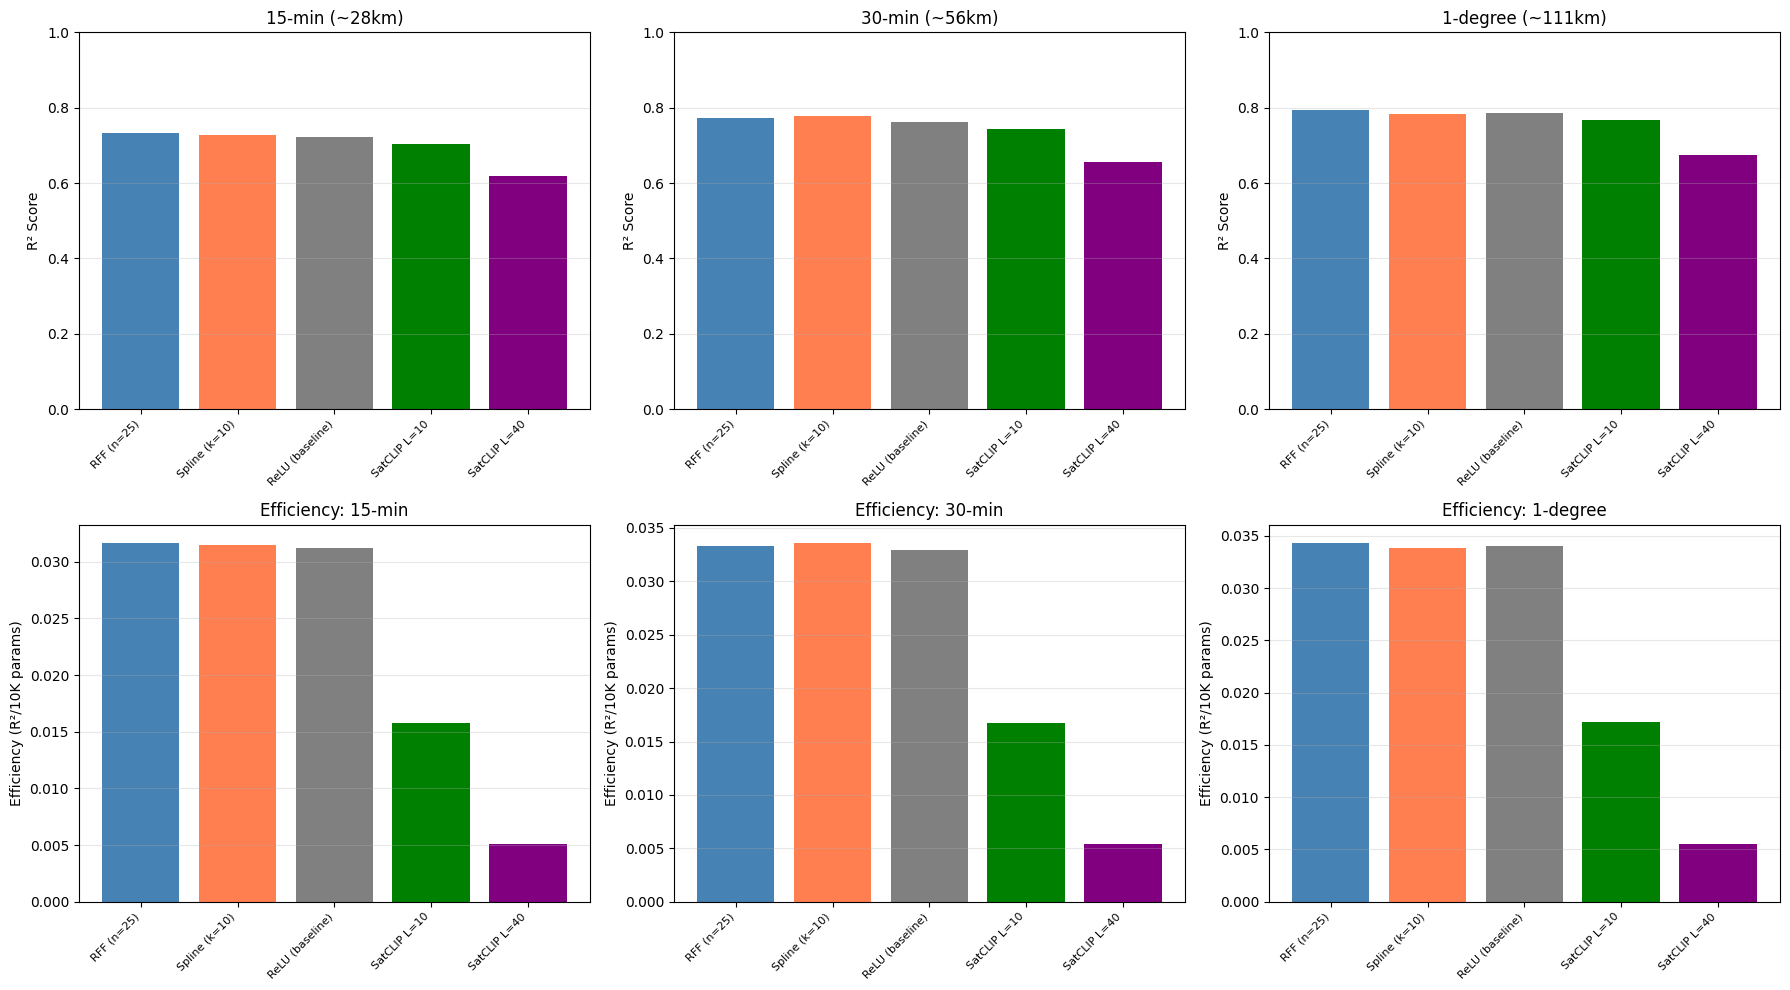

In [13]:
# Comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

resolutions = ['15-min', '30-min', '1-degree']
colors = {'RFF (n=25)': 'steelblue', 'Spline (k=10)': 'coral', 'ReLU (baseline)': 'gray',
          'SatCLIP L=10': 'green', 'SatCLIP L=40': 'purple'}

# Row 1: R² by resolution
for i, res_name in enumerate(resolutions):
    ax = axes[0, i]
    df_res = df_all[df_all['resolution'] == res_name]
    models = df_res['model'].tolist()
    r2s = df_res['r2'].tolist()
    ax.bar(range(len(models)), r2s, color=[colors[m] for m in models])
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('R² Score')
    ax.set_title(f'{res_name} ({RESOLUTIONS[res_name]["desc"]})')
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3, axis='y')

# Row 2: Efficiency and cross-resolution comparison
for i, res_name in enumerate(resolutions):
    ax = axes[1, i]
    df_res = df_all[df_all['resolution'] == res_name]
    models = df_res['model'].tolist()
    effs = df_res['efficiency'].tolist()
    ax.bar(range(len(models)), effs, color=[colors[m] for m in models])
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Efficiency (R²/10K params)')
    ax.set_title(f'Efficiency: {res_name}')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('multi_resolution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

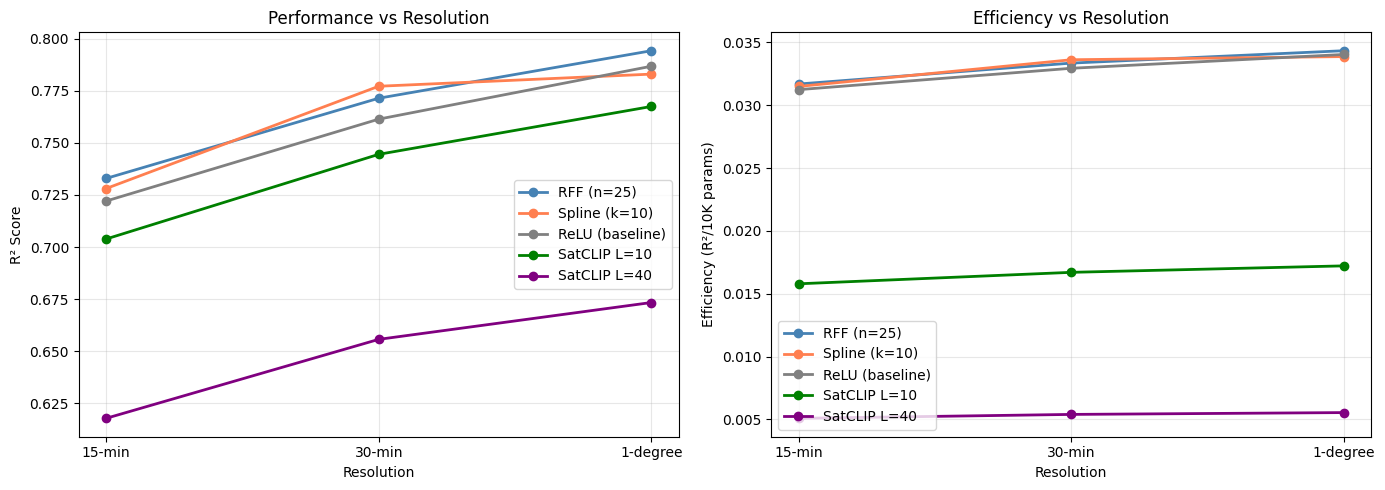

In [14]:
# Resolution scaling plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: R² vs Resolution
ax = axes[0]
for model in ['RFF (n=25)', 'Spline (k=10)', 'ReLU (baseline)', 'SatCLIP L=10', 'SatCLIP L=40']:
    df_model = df_all[df_all['model'] == model]
    r2s = [df_model[df_model['resolution'] == r]['r2'].values[0] for r in resolutions]
    ax.plot(resolutions, r2s, marker='o', linewidth=2, label=model, color=colors[model])
ax.set_xlabel('Resolution')
ax.set_ylabel('R² Score')
ax.set_title('Performance vs Resolution')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Efficiency vs Resolution
ax = axes[1]
for model in ['RFF (n=25)', 'Spline (k=10)', 'ReLU (baseline)', 'SatCLIP L=10', 'SatCLIP L=40']:
    df_model = df_all[df_all['model'] == model]
    effs = [df_model[df_model['resolution'] == r]['efficiency'].values[0] for r in resolutions]
    ax.plot(resolutions, effs, marker='o', linewidth=2, label=model, color=colors[model])
ax.set_xlabel('Resolution')
ax.set_ylabel('Efficiency (R²/10K params)')
ax.set_title('Efficiency vs Resolution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('resolution_scaling.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Save results
df_all.to_csv('multi_resolution_results.csv', index=False)
print("Results saved!")

print("\n" + "="*80)
print("KEY TAKEAWAYS")
print("="*80)
print("""
1. How do learned activations perform vs SatCLIP at different resolutions?
   - Look at the R² comparison above

2. Does resolution affect the relative advantage of learned activations?
   - Check the resolution scaling plots

3. Which model has the best efficiency?
   - Look at efficiency bars and summary table

4. Based on notebook 14 results (RFF won at 15-min):
   - Does RFF maintain its advantage at coarser resolutions?
   - Should we try more RFF features (50, 100)?
   - Should we combine RFF with SH encoding (Phase 1 of roadmap)?
""")

Results saved!

KEY TAKEAWAYS

1. How do learned activations perform vs SatCLIP at different resolutions?
   - Look at the R² comparison above
   
2. Does resolution affect the relative advantage of learned activations?
   - Check the resolution scaling plots
   
3. Which model has the best efficiency?
   - Look at efficiency bars and summary table
   
4. Based on notebook 14 results (RFF won at 15-min):
   - Does RFF maintain its advantage at coarser resolutions?
   - Should we try more RFF features (50, 100)?
   - Should we combine RFF with SH encoding (Phase 1 of roadmap)?

